In [ ]:
# Install required packages
!pip install -U ultralytics
import os
import zipfile
import pandas as pd
from google.colab import drive
from ultralytics import YOLO
from IPython.display import Image, display, Markdown

# Mount Google Drive as required by SA2 instructions
print("Mounting Google Drive...")
drive.mount('/content/drive')

# Define paths
zip_path = "/content/drive/MyDrive/roboflowdata.zip"  # Change this if your zip is in a subfolder
extract_dir = "/content/dataset"

# Extract the dataset directly to Colab's storage
if os.path.exists(zip_path):
    print(f"Extracting {zip_path}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print(f" Successfully extracted dataset to {extract_dir}/")
else:
    print(f" Error: {zip_path} not found. Please upload roboflowdata.zip to your Google Drive.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 52.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Mounting Google Drive...
Mounted at /content/drive
Extracting /content/drive/MyDrive/roboflowdata.zip...
 Successfully extracted dataset to /content/dataset/


In [ ]:
# Original to New mapping
CLASS_MAP = {
    3: 0,  # car -> 0
    2: 1,  # bus -> 1
    7: 2   # motorcycle -> 2
}

def clean_labels(label_dir):
    if not os.path.exists(label_dir):
        return

    for file in os.listdir(label_dir):
        if not file.endswith(".txt"):
            continue

        filepath = os.path.join(label_dir, file)
        new_lines = []

        with open(filepath, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if not parts: continue
                cls = int(parts[0])
                if cls in CLASS_MAP:
                    parts[0] = str(CLASS_MAP[cls])
                    new_lines.append(" ".join(parts))

        # Overwrite with clean labels
        with open(filepath, "w") as f:
            f.write("\n".join(new_lines))

# Clean train, valid, and test labels
clean_labels(os.path.join(extract_dir, "train", "labels"))
clean_labels(os.path.join(extract_dir, "valid", "labels"))
clean_labels(os.path.join(extract_dir, "test", "labels"))
print(" Labels successfully mapped to 0, 1, 2.")

 Labels successfully mapped to 0, 1, 2.


In [ ]:
# Create YAML using absolute paths for Colab
yaml_content = f"""
path: /content/dataset
train: train/images
val: valid/images
test: test/images

names:
  0: car
  1: bus
  2: motorcycle
"""

with open("dataset.yaml", "w") as f:
    f.write(yaml_content)
print(" dataset.yaml created successfully.")

# Define the 3 experimental setups as required by the SA2 instructions
experiments = [
    {"name": "model_A", "epochs": 25, "optimizer": "AdamW", "batch": 4, "lr0": 0.01, "imgsz": 640},
    {"name": "model_B", "epochs": 30, "optimizer": "SGD", "batch": 20, "lr0": 0.001, "imgsz": 640},
    {"name": "model_C", "epochs": 40, "optimizer": "auto", "batch": -1, "lr0": 0.0001, "imgsz": 640}
]

print("\n Deliverable 3: Hyperparameter Settings Table")
display(pd.DataFrame(experiments))

 dataset.yaml created successfully.

 Deliverable 3: Hyperparameter Settings Table


,name,epochs,optimizer,batch,lr0,imgsz
0,model_A,25,AdamW,4,0.0100,640
1,model_B,30,SGD,20,0.0010,640
2,model_C,40,auto,-1,0.0001,640


In [ ]:
print(" Starting Model Initialization & Training...")

for exp in experiments:
    name = exp["name"]
    print(f"\n=========================================")
    print(f" Training {name} for {exp['epochs']} epochs...")
    print(f"=========================================")

    # Initialize the model
    model = YOLO("yolo26n.pt")

    # Execute the training command
    model.train(
        data="dataset.yaml",
        epochs=exp["epochs"],
        imgsz=exp["imgsz"],
        optimizer=exp["optimizer"],
        batch=exp["batch"],
        lr0=exp["lr0"],
        project="/content/runs_yolo26",
        name=name
    )

    print(f" Finished training {name}.")

 Starting Model Initialization & Training...

 Training model_A for 25 epochs...
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=model_A, nbs=64, nms=False, opset=None, optimize=Fa

In [ ]:
print("📈 Running Validation and Generating Performance Metrics...")

metrics_data = []

for exp in experiments:
    name = exp["name"]
    # Point to the best weights generated from the training loop
    best_weights_path = f"/content/runs_yolo26/{name}/weights/best.pt"

    if os.path.exists(best_weights_path):
        # Load the trained model
        trained_model = YOLO(best_weights_path)

        # Run the validation module
        print(f"\n🔍 Validating {name}...")
        val_metrics = trained_model.val(data="dataset.yaml")

        # Extract metrics
        precision = val_metrics.results_dict['metrics/precision(B)']
        recall = val_metrics.results_dict['metrics/recall(B)']
        map50 = val_metrics.results_dict['metrics/mAP50(B)']

        # Calculate F1 Score
        if (precision + recall) > 0:
            f1_score = 2 * (precision * recall) / (precision + recall)
        else:
            f1_score = 0

        metrics_data.append({
            "Model": name,
            "mAP50": round(map50, 4),
            "Precision": round(precision, 4),
            "Recall": round(recall, 4),
            "F1 Score": round(f1_score, 4)
        })
    else:
        print(f"❌ Could not find weights for {name} at {best_weights_path}")

print("\n📊 Deliverable 4: Model Metrics Results")
display(pd.DataFrame(metrics_data))

📈 Running Validation and Generating Performance Metrics...

🔍 Validating model_A...
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,421 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2058.7±520.1 MB/s, size: 51.0 KB)
val: Scanning /content/dataset/valid/labels.cache... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 38.1Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 1126, len(boxes) = 1137. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 2.3it/s 3.0s
                   all        100       1137      0.688      0.556      0.608      0.475
                   car        100       1104  

,Model,mAP50,Precision,Recall,F1 Score
0,model_A,0.6084,0.6881,0.5556,0.6148
1,model_B,0.3102,0.9258,0.2515,0.3956
2,model_C,0.7763,0.7878,0.6793,0.7295


🟩 Deliverable 2: Confusion Matrices


### Confusion Matrix for model_A

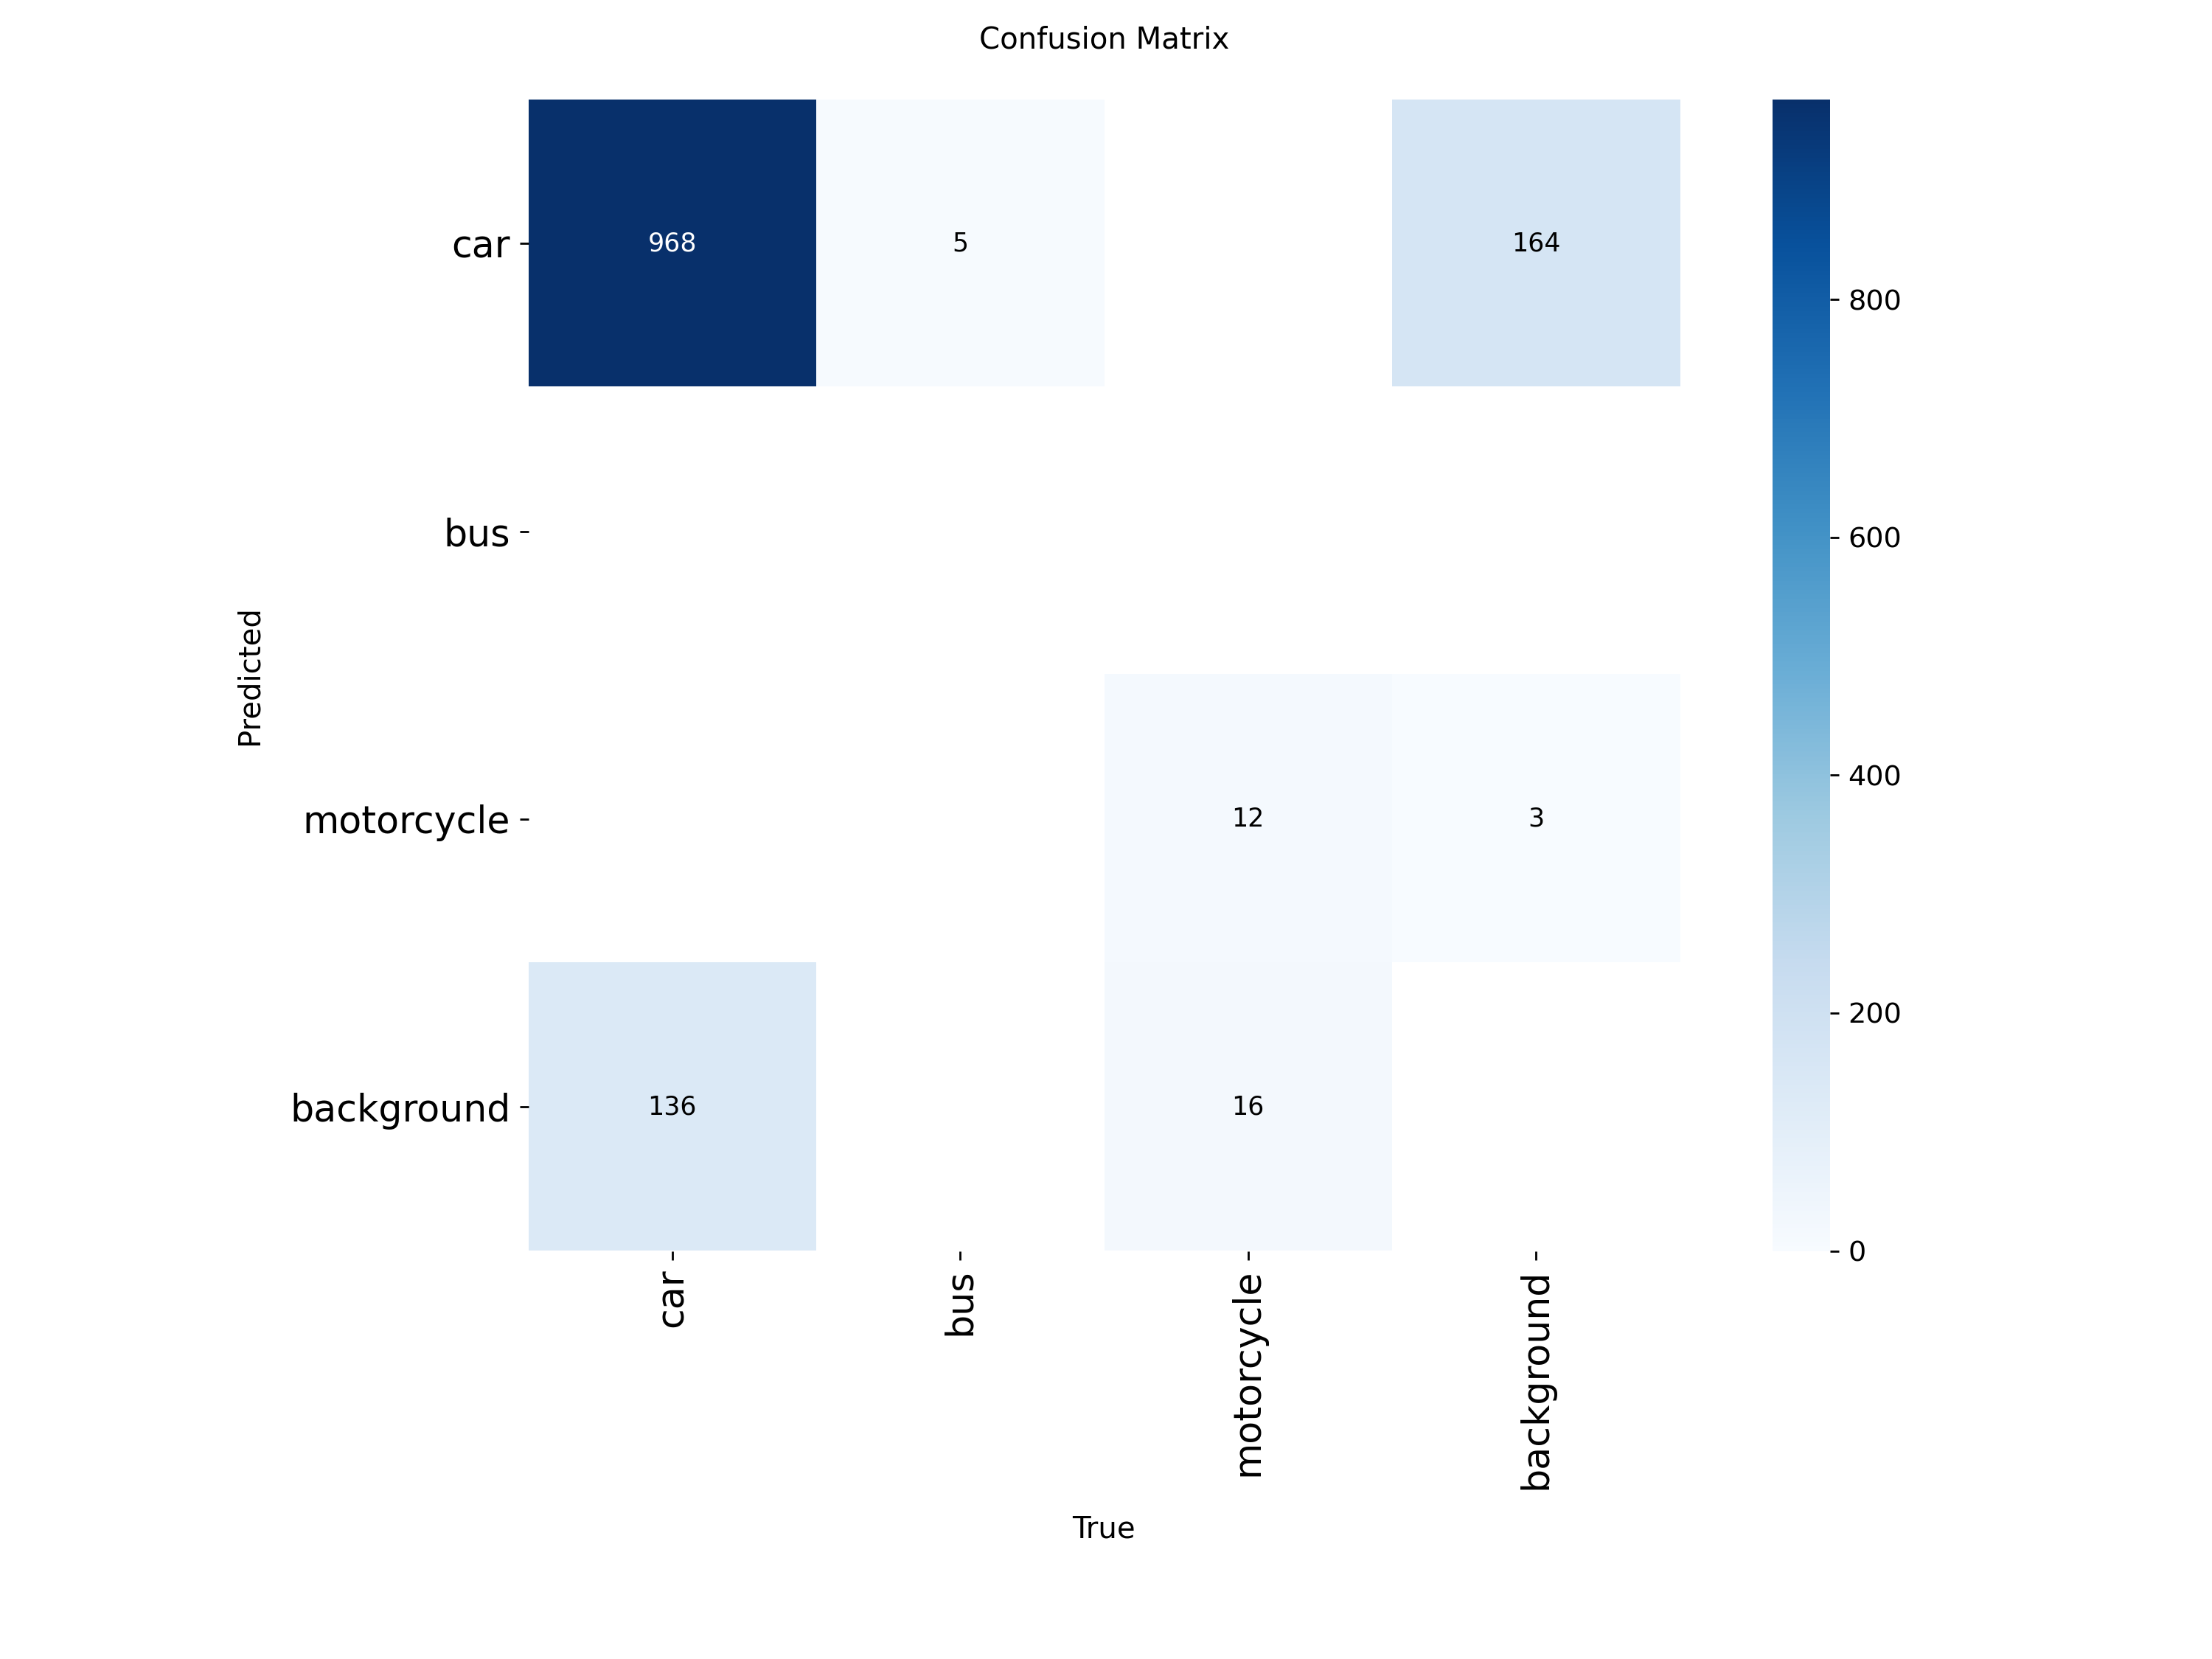

### Confusion Matrix for model_B

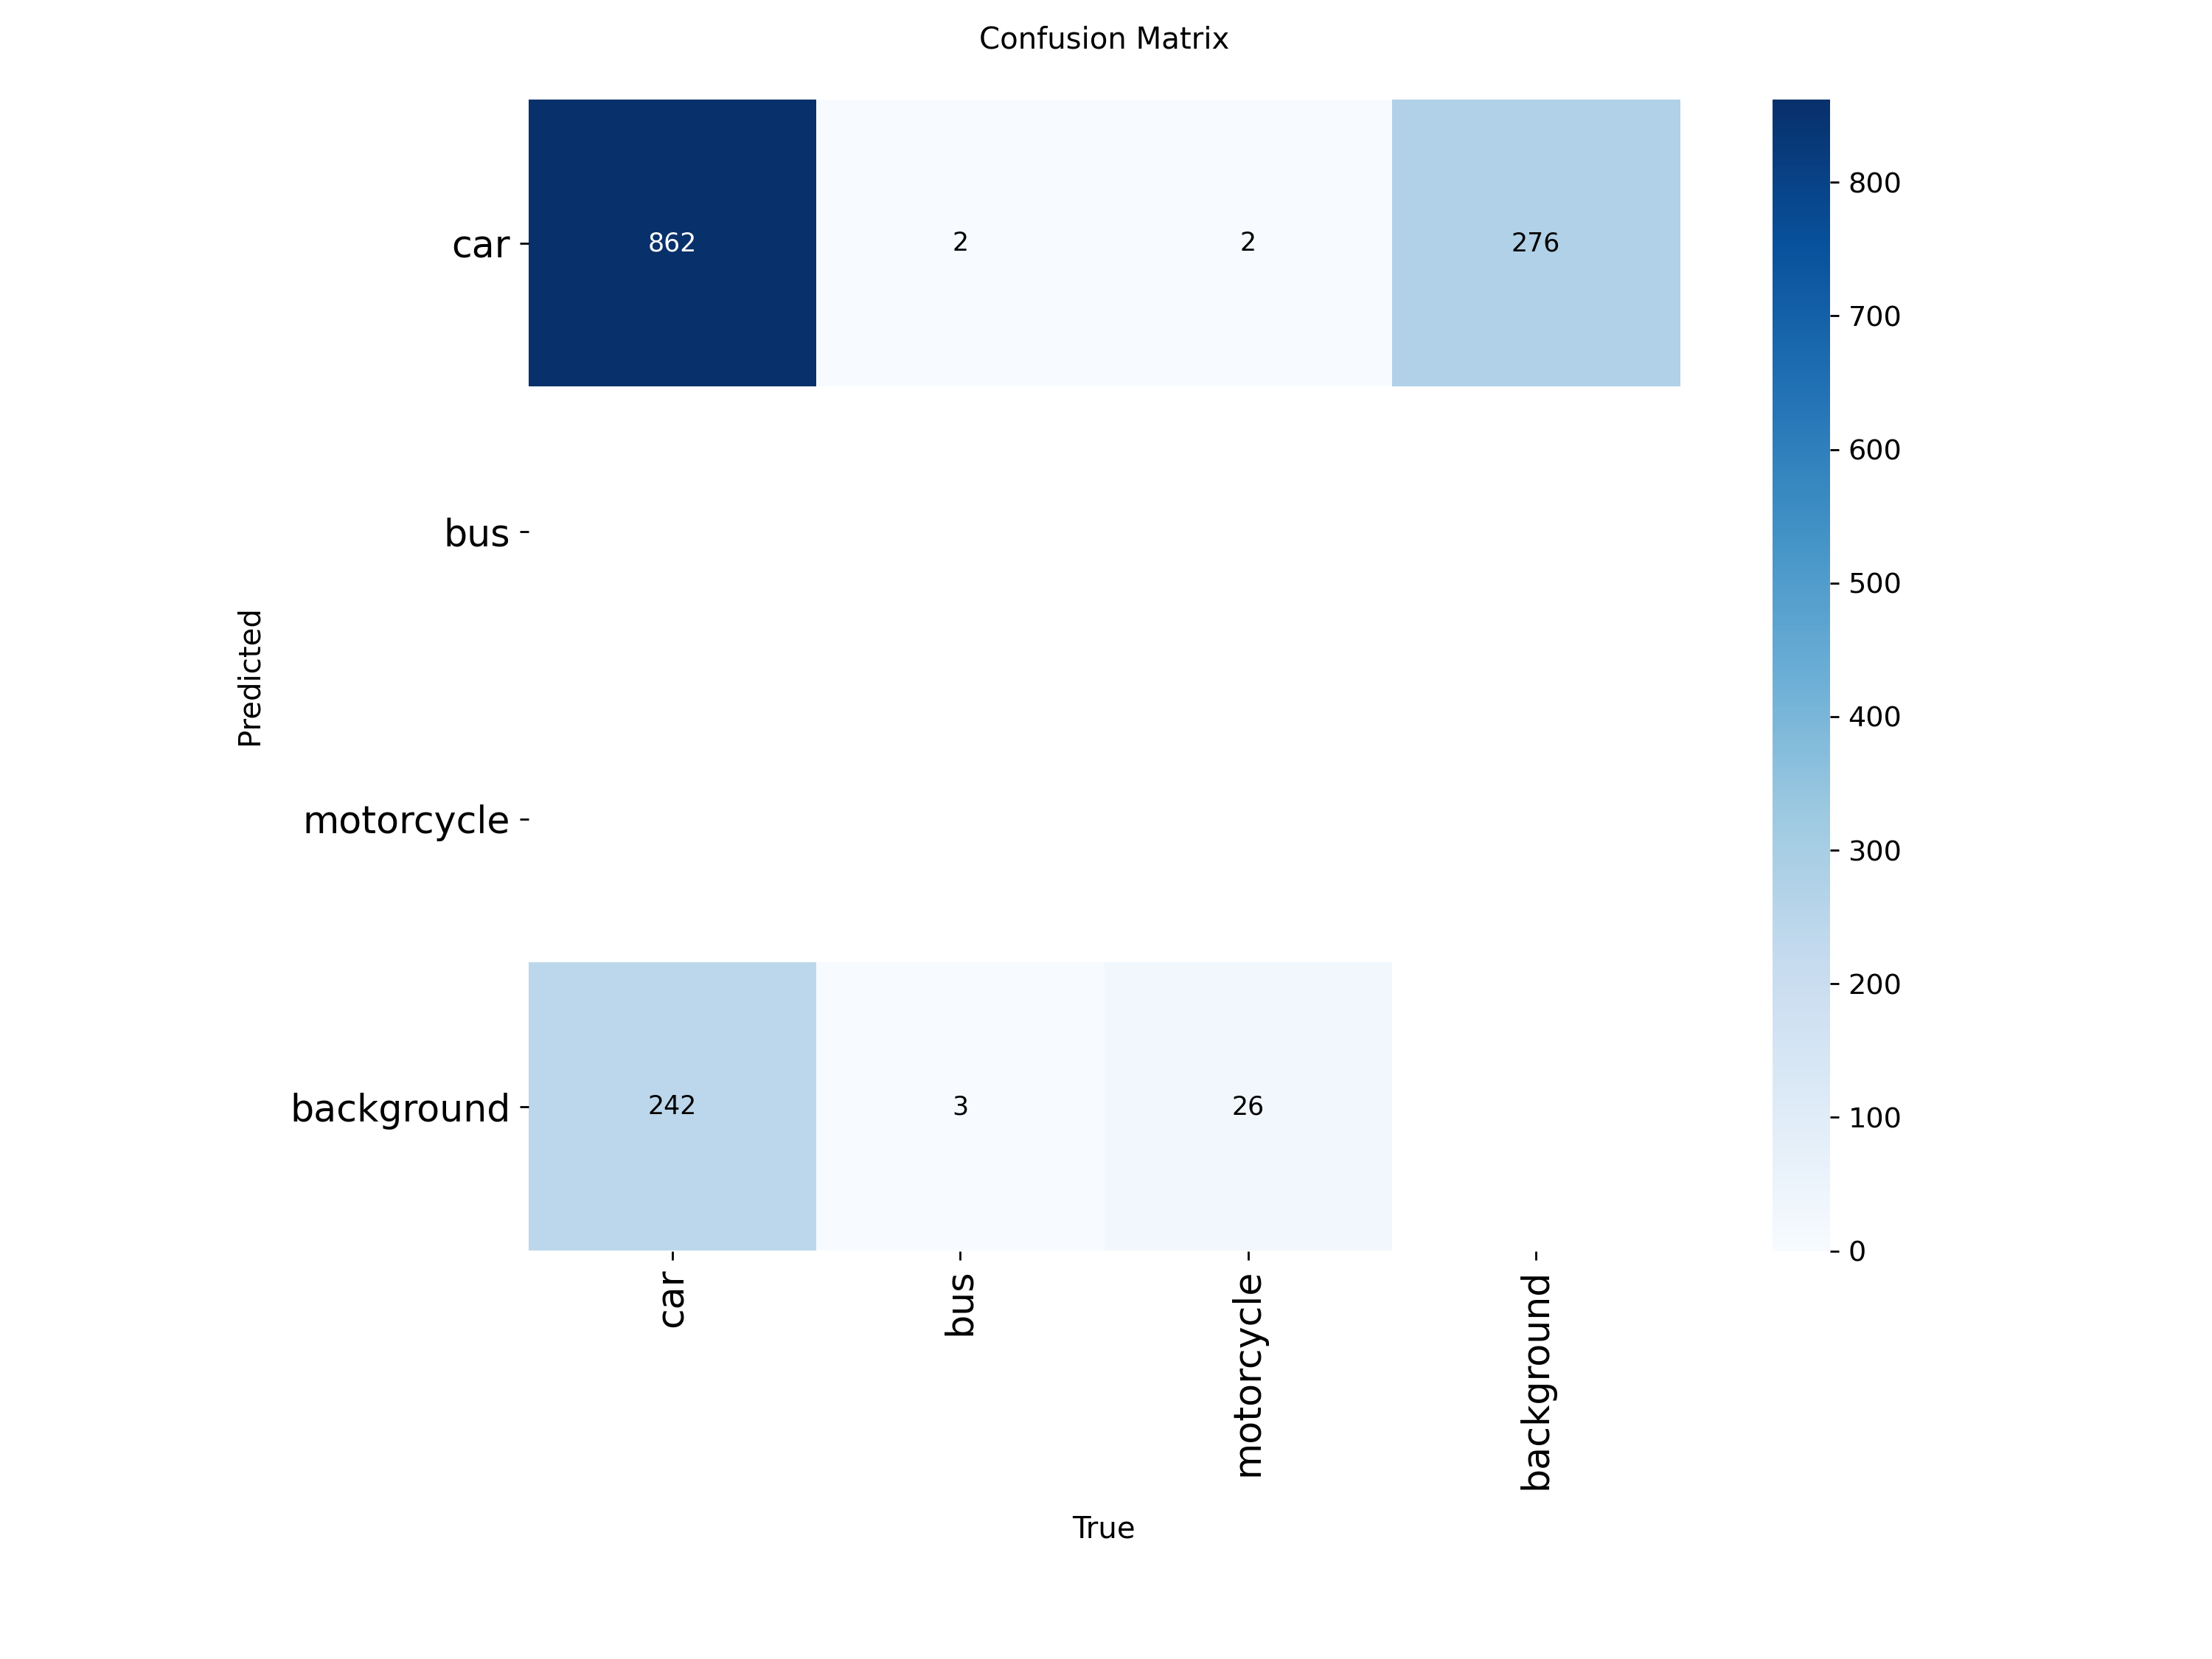

### Confusion Matrix for model_C

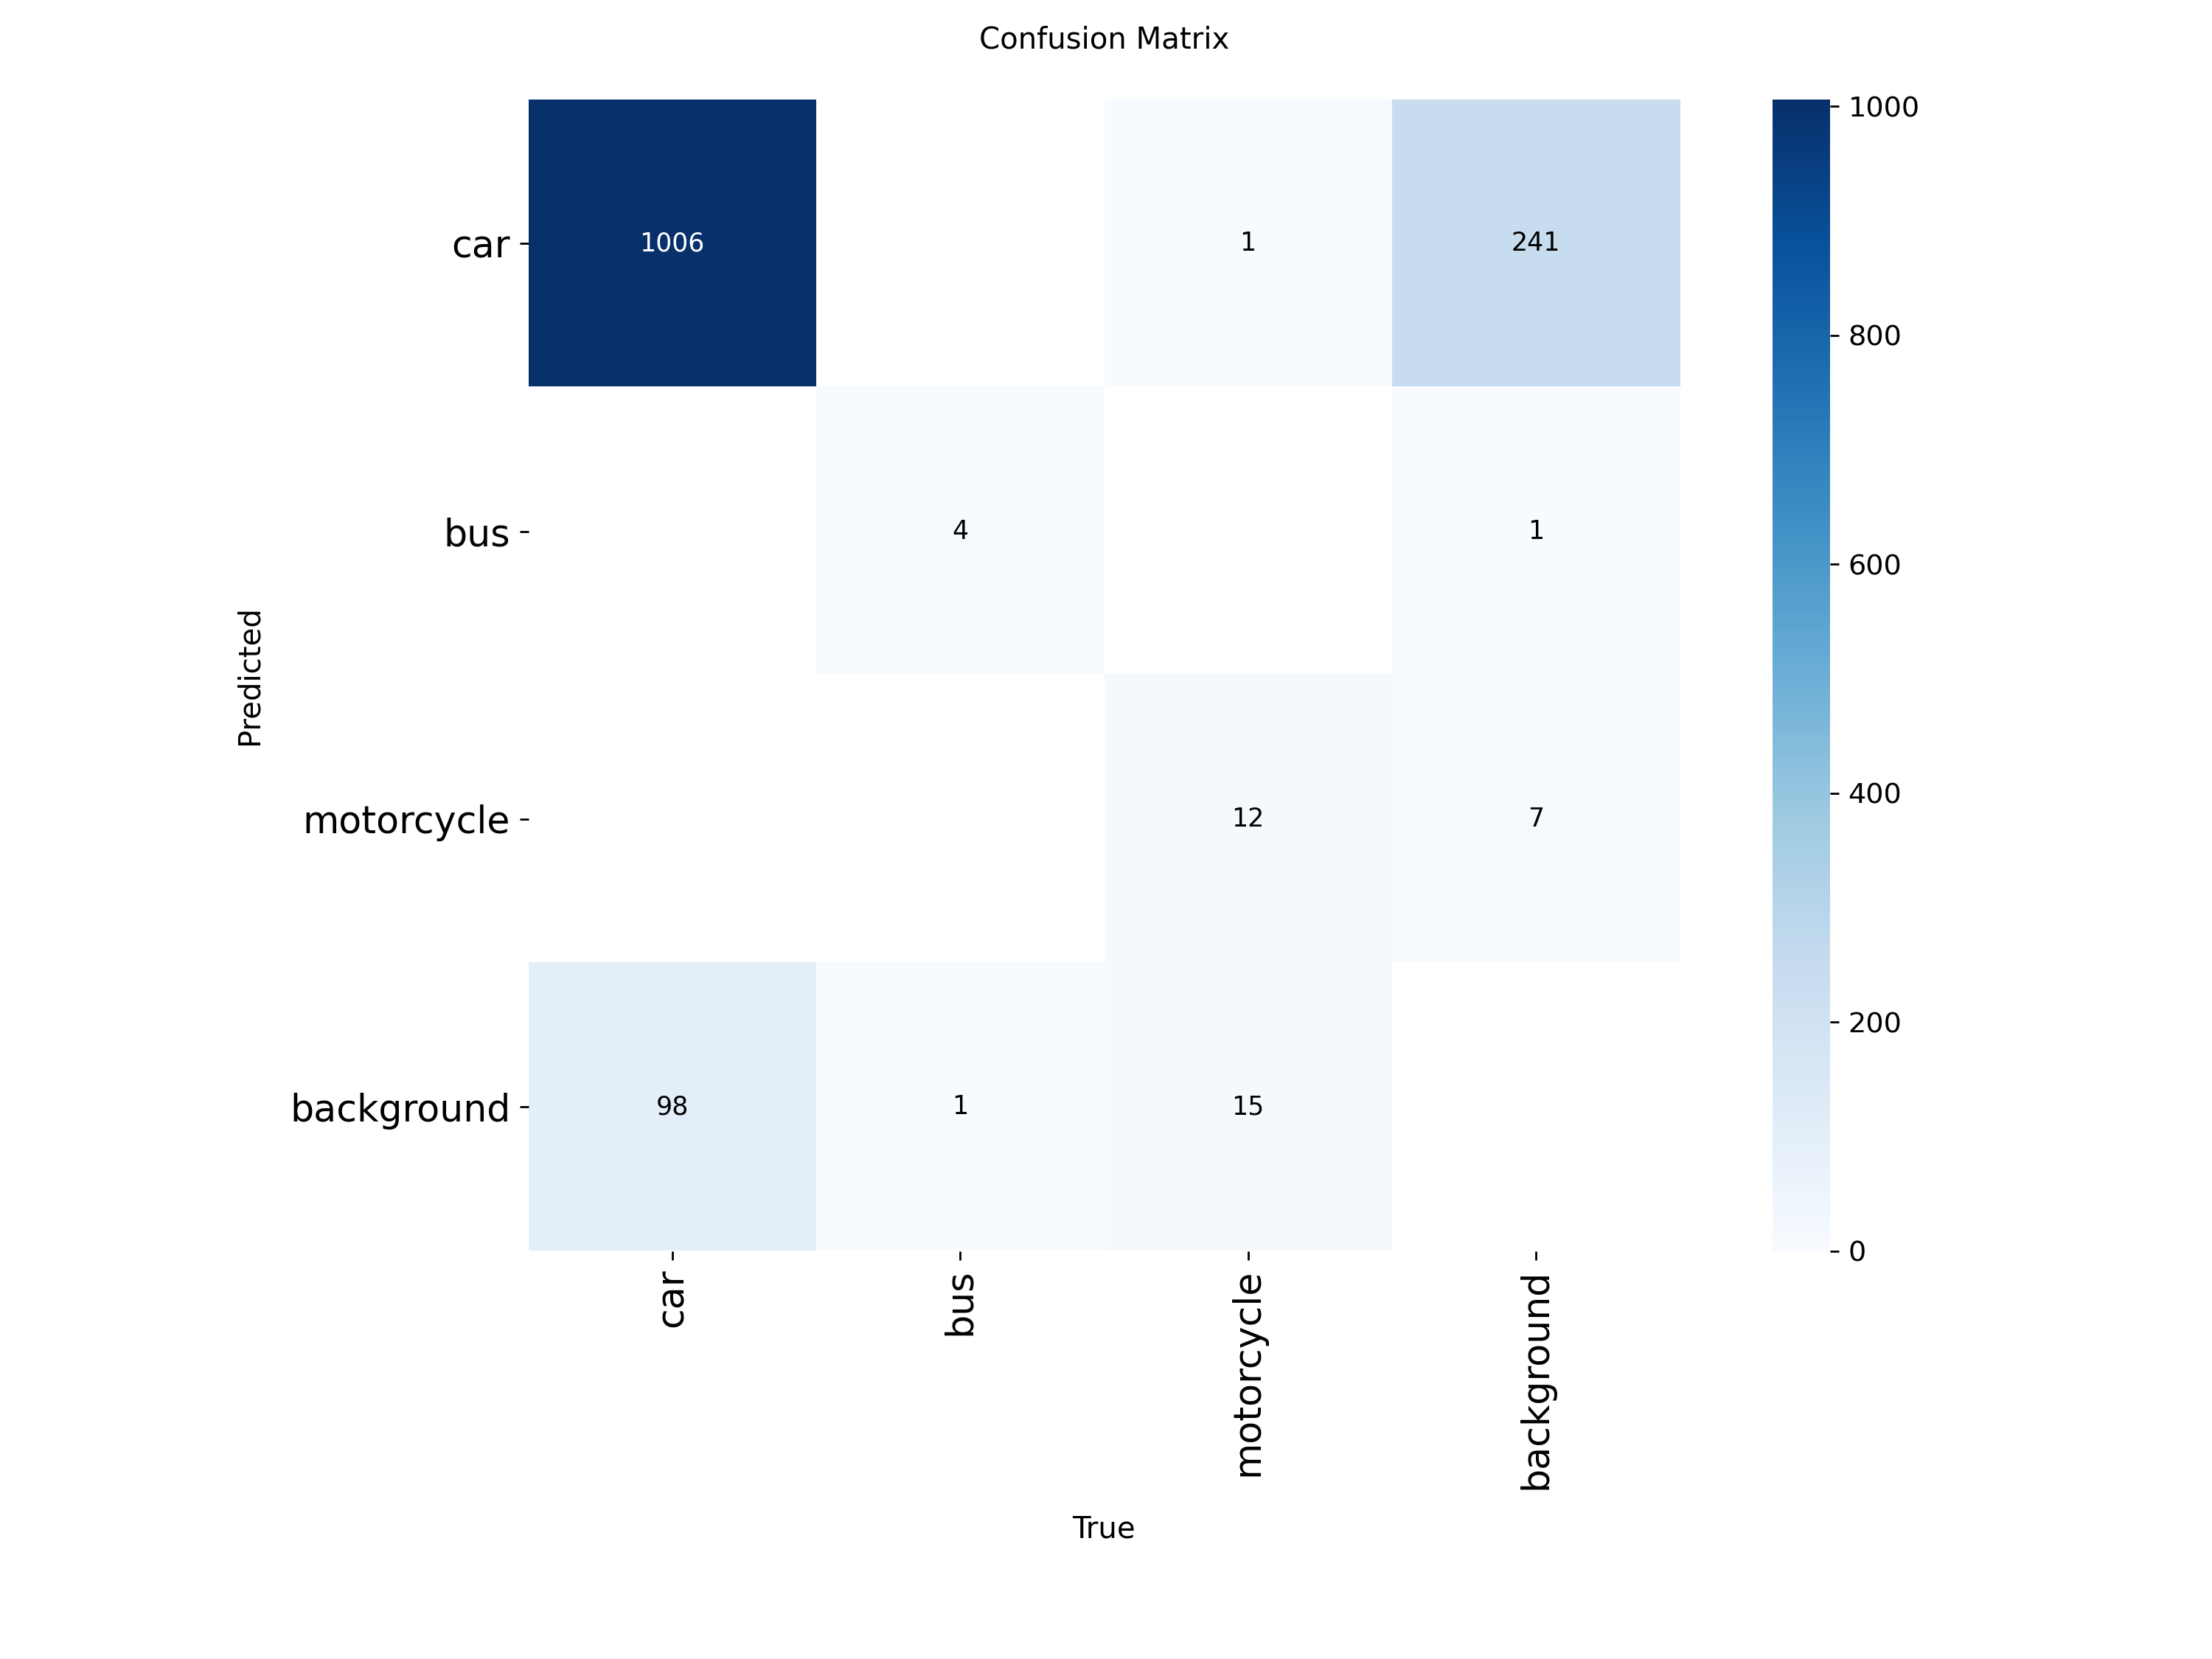

In [ ]:
print("🟩 Deliverable 2: Confusion Matrices")

for exp in experiments:
    name = exp["name"]
    matrix_path = f"/content/runs_yolo26/{name}/confusion_matrix.png"

    if os.path.exists(matrix_path):
        display(Markdown(f"### Confusion Matrix for {name}"))
        display(Image(filename=matrix_path, width=800))
    else:
        print(f"❌ Confusion matrix not found for {name} at {matrix_path}")

In [ ]:
import os
import pandas as pd
from IPython.display import display

metrics_data = []
experiments = ["model_A", "model_B", "model_C"]

for name in experiments:
    # Pointing to the CSV file generated during training
    results_path = f"/content/runs_yolo26/{name}/results.csv"

    if os.path.exists(results_path):
        df = pd.read_csv(results_path)

        # YOLO columns often generate with leading spaces, this cleans them up
        df.columns = df.columns.str.strip()

        # Grab the metrics from the very last training epoch
        last_epoch = df.iloc[-1]

        precision = last_epoch['metrics/precision(B)']
        recall = last_epoch['metrics/recall(B)']
        map50 = last_epoch['metrics/mAP50(B)']

        # Calculate the F1 Score
        if (precision + recall) > 0:
            f1_score = 2 * (precision * recall) / (precision + recall)
        else:
            f1_score = 0

        metrics_data.append({
            "Model": name,
            "mAP50": round(map50, 4),
            "Precision": round(precision, 4),
            "Recall": round(recall, 4),
            "F1 Score": round(f1_score, 4)
        })
    else:
        print(f" Results CSV not found for {name}. Make sure training finished!")

# Generate the DataFrame and display it
df_metrics = pd.DataFrame(metrics_data)

print("\n Deliverable 4: Models' Metrics Results")
display(df_metrics)


📈 Deliverable 4: Models' Metrics Results


,Model,mAP50,Precision,Recall,F1 Score
0,model_A,0.6090,0.6886,0.5556,0.6150
1,model_B,0.3104,0.9257,0.2516,0.3956
2,model_C,0.7794,0.7996,0.7531,0.7756
